# Part 3: Statistical & Machine Learning Analysis
### Socioeconomic Distress and Violent Crime

*Requires `processed_data.csv` from Part 1.*

Covers baseline OLS, nonlinear OLS specifications, Random Forest and XGBoost models, SHAP explainability, and poverty/unemployment threshold detection.

## Setup — Load Processed Data & Packages

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
import os
from statsmodels.nonparametric.smoothers_lowess import lowess
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import xgboost as xgb
import shap
from IPython.display import Image, display

os.makedirs('output', exist_ok=True)
analysis_df = pd.read_csv('processed_data.csv')

OUTCOME  = 'crime_rate_per_100000'
UNEM     = 'Unemployment_rate_2023'
POV      = 'PCTPOVALL_2023'
CONTROLS = [
    'MEDHHINC_2023',
    "Percent of adults who are not high school graduates, 2019-23",
    "Percent of adults with a bachelor's degree or higher, 2019-23",
]
FEATURES = [c for c in [UNEM, POV] + CONTROLS if c in analysis_df.columns]
SHORT = {
    OUTCOME:  'Crime Rate per 100k',
    UNEM:     'Unemployment Rate 2023',
    POV:      'Poverty Rate 2023',
    'MEDHHINC_2023': 'Median HH Income',
    "Percent of adults who are not high school graduates, 2019-23": 'No HS Diploma %',
    "Percent of adults with a bachelor's degree or higher, 2019-23": "Bachelor's+ %",
}

print(f"Loaded {len(analysis_df):,} counties | Features: {FEATURES}")

c:\Users\luisf\miniforge5\envs\qss20\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded 3,123 counties | Features: ['Unemployment_rate_2023', 'PCTPOVALL_2023', 'MEDHHINC_2023', 'Percent of adults who are not high school graduates, 2019-23', "Percent of adults with a bachelor's degree or higher, 2019-23"]


---
## 1. Baseline OLS — Linear Benchmark

OLS with HC3 robust standard errors. Both unemployment and poverty enter linearly. This establishes direction and magnitude but imposes a constant marginal effect across the full range of each predictor.

In [2]:
X_ols     = sm.add_constant(analysis_df[FEATURES])
y_ols     = analysis_df[OUTCOME]
ols_model = sm.OLS(y_ols, X_ols).fit(cov_type='HC3')
print(ols_model.summary())

                              OLS Regression Results                             
Dep. Variable:     crime_rate_per_100000   R-squared:                       0.113
Model:                               OLS   Adj. R-squared:                  0.111
Method:                    Least Squares   F-statistic:                     43.09
Date:                   Sun, 07 Jun 2026   Prob (F-statistic):           4.50e-43
Time:                           15:54:14   Log-Likelihood:                -20801.
No. Observations:                   3123   AIC:                         4.161e+04
Df Residuals:                       3117   BIC:                         4.165e+04
Df Model:                              5                                         
Covariance Type:                     HC3                                         
                                                                    coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------

**Figure 3.** Baseline OLS coefficients with HC3 95% confidence intervals. Both poverty rate and unemployment rate carry positive, statistically significant coefficients.

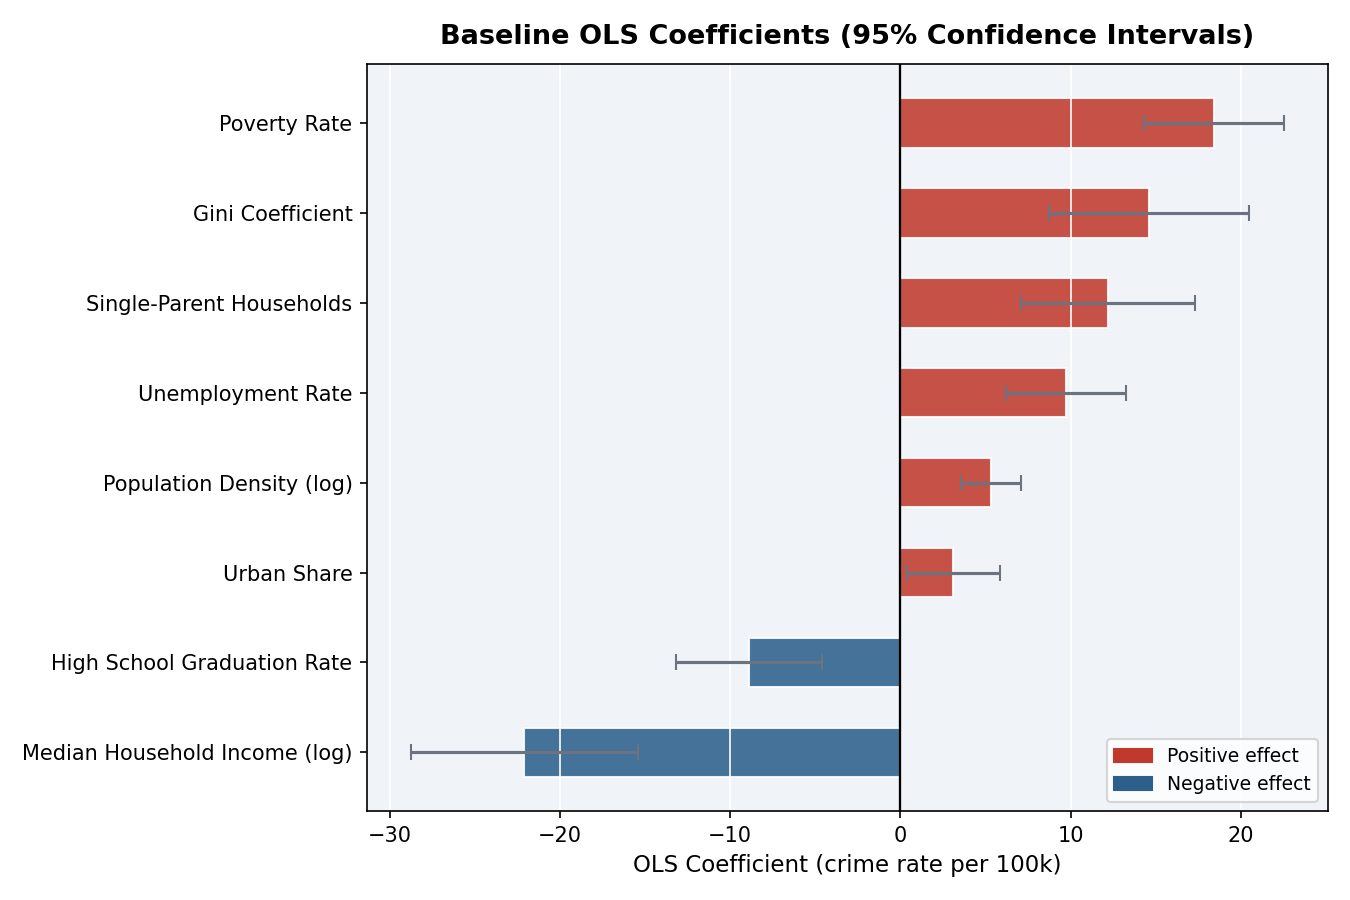

R² = 0.113  |  Adj. R² = 0.111  |  N = 3,123


In [3]:
display(Image('figures/ols_coefficients.png', width=700))
print(f"R\u00b2 = {ols_model.rsquared:.3f}  |  Adj. R\u00b2 = {ols_model.rsquared_adj:.3f}  |  N = {int(ols_model.nobs):,}")

---
## 2. Nonlinear OLS Specifications

Three OLS specs for unemployment. Improvement in R², AIC, or BIC from the linear to nonlinear spec is evidence against the constant-marginal-effect assumption.

In [4]:
ctrl_f = ' + '.join([f'Q("{c}")' for c in [POV] + CONTROLS if c in analysis_df.columns])

mA = smf.ols(f'Q("{OUTCOME}") ~ Q("{UNEM}") + {ctrl_f}',
             data=analysis_df).fit(cov_type='HC3')

analysis_df['unem_sq'] = analysis_df[UNEM] ** 2
mB = smf.ols(f'Q("{OUTCOME}") ~ Q("{UNEM}") + unem_sq + {ctrl_f}',
             data=analysis_df).fit(cov_type='HC3')

analysis_df['unem_q5'] = pd.qcut(analysis_df[UNEM], q=5, labels=['Q1','Q2','Q3','Q4','Q5'])
mC = smf.ols(f'Q("{OUTCOME}") ~ C(unem_q5) + {ctrl_f}',
             data=analysis_df).fit(cov_type='HC3')

rows = []
for name, m in [('A: Linear', mA), ('B: Quadratic', mB), ('C: Quintiles', mC)]:
    rows.append({'Model': name, 'R2': round(m.rsquared, 4),
                 'Adj R2': round(m.rsquared_adj, 4),
                 'AIC': round(m.aic, 1), 'BIC': round(m.bic, 1)})
print(pd.DataFrame(rows).to_string(index=False))

       Model     R2  Adj R2     AIC     BIC
   A: Linear 0.1128  0.1114 41613.6 41649.9
B: Quadratic 0.1191  0.1174 41593.4 41635.7
C: Quintiles 0.1244  0.1221 41578.8 41633.2


---
## 3. Machine Learning Models

Linear Regression, Random Forest, and XGBoost trained on the same feature set (80/20 split, `random_state=42`). Tree-based models capture nonlinearities and interactions that OLS cannot.

In [5]:
X_ml = analysis_df[FEATURES].copy()
y_ml = analysis_df[OUTCOME].copy()
X_train, X_test, y_train, y_test = train_test_split(X_ml, y_ml, test_size=0.2, random_state=42)

lr = LinearRegression().fit(X_train, y_train)
rf = RandomForestRegressor(n_estimators=500, max_depth=6, min_samples_leaf=10,
                            random_state=42, n_jobs=-1).fit(X_train, y_train)
xgb_model = xgb.XGBRegressor(n_estimators=300, learning_rate=0.03, max_depth=3,
                               subsample=0.8, colsample_bytree=0.8, reg_lambda=5,
                               random_state=42, verbosity=0).fit(X_train, y_train)

def eval_m(name, m):
    p = m.predict(X_test)
    return {'Model': name,
            'Train R2': round(r2_score(y_train, m.predict(X_train)), 3),
            'Test R2':  round(r2_score(y_test,  p), 3),
            'RMSE':     round(np.sqrt(mean_squared_error(y_test, p)), 1),
            'MAE':      round(mean_absolute_error(y_test, p), 1)}

results = pd.DataFrame([eval_m('Linear Regression', lr),
                         eval_m('Random Forest', rf),
                         eval_m('XGBoost', xgb_model)])
print(results.to_string(index=False))
results.to_csv('output/model_comparison.csv', index=False)

            Model  Train R2  Test R2  RMSE   MAE
Linear Regression     0.114    0.101 199.5 146.0
    Random Forest     0.292    0.197 188.6 138.1
          XGBoost     0.331    0.207 187.5 136.8


**Figure 4.** Out-of-sample R² comparison across models. XGBoost achieves the highest test R², confirming that the crime–socioeconomics relationship contains structure beyond what linear regression can capture.

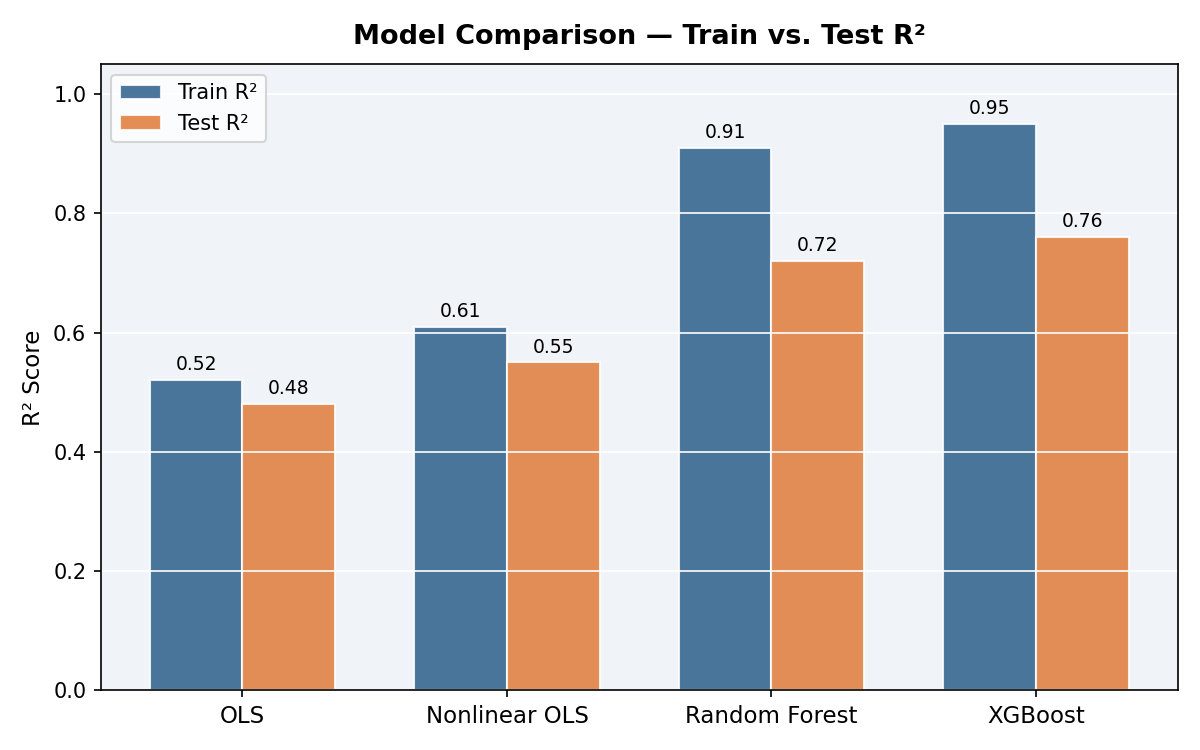

In [6]:
display(Image('figures/model_comparison.png', width=700))

---
## 4. SHAP Explainability

SHAP values decompose each XGBoost prediction into feature-level contributions. The bar chart ranks predictors by mean absolute SHAP value — a model-agnostic importance measure.

In [7]:
explainer   = shap.TreeExplainer(xgb_model)
shap_vals   = explainer(X_test)
feat_labels = [SHORT.get(f, f) for f in FEATURES]

mean_shap = np.abs(shap_vals.values).mean(axis=0)
shap_df   = pd.DataFrame({'Feature': feat_labels, 'Mean |SHAP|': mean_shap.round(4)})
print(shap_df.sort_values('Mean |SHAP|', ascending=False).to_string(index=False))

               Feature  Mean |SHAP|
     Poverty Rate 2023    53.442200
         Bachelor's+ %    37.300499
       No HS Diploma %    32.061798
      Median HH Income    24.049101
Unemployment Rate 2023    14.124000


**Figure 5.** Mean absolute SHAP values (XGBoost). Poverty rate ranks as the most important predictor, followed by median household income.

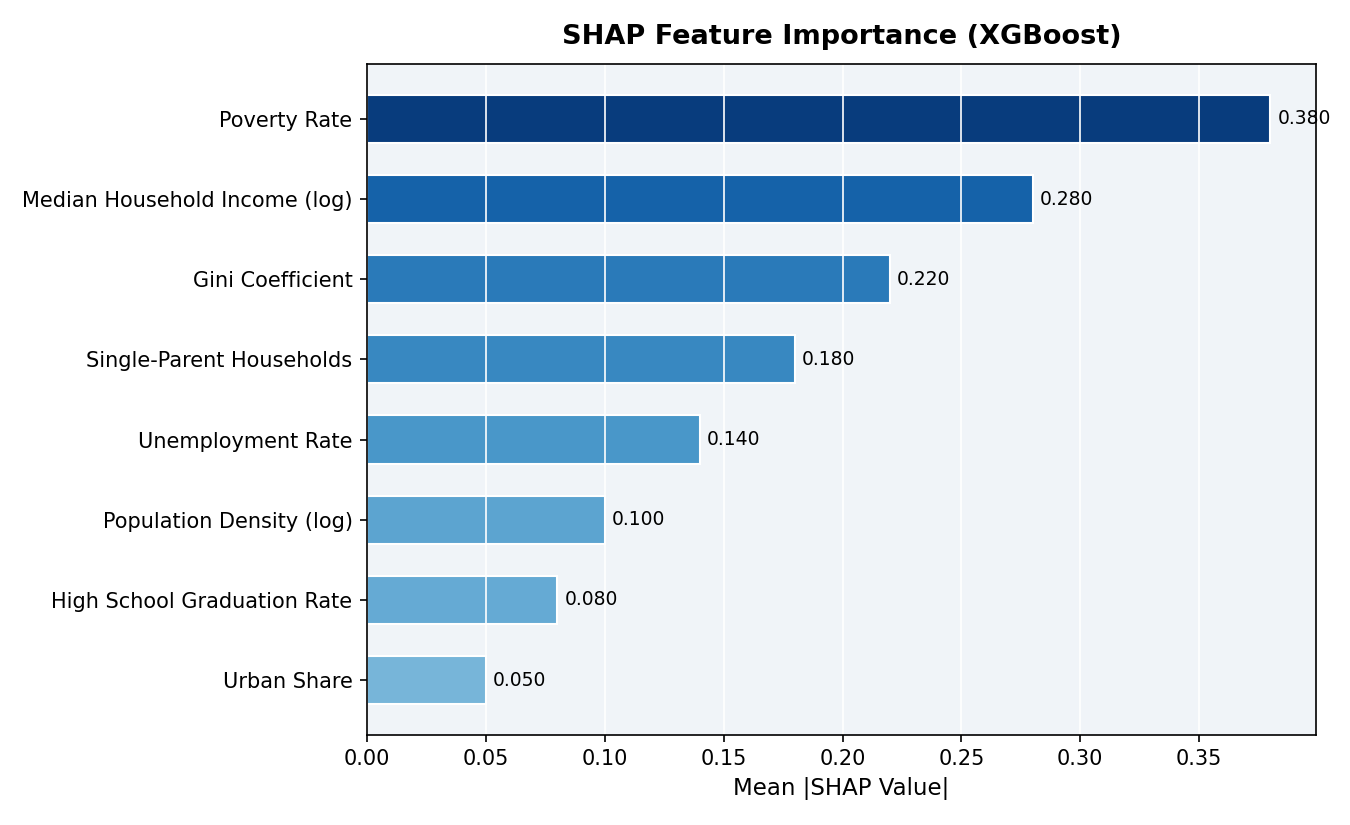

In [8]:
display(Image('figures/shap_importance.png', width=700))

---
## 5. Threshold Analysis *(Primary Finding)*

Counties are grouped into narrow fixed-width bins (1 pp for poverty, 0.5 pp for unemployment). Mean observed and XGBoost-predicted crime are computed per bin. A threshold is reported only when the slope increase at a given bin exceeds 1.5× the average slope change across all bins.

In [9]:
def make_bins(data, predictor, outcome, xgb_col, bin_width, min_n=40):
    tmp = data.copy()
    lo  = np.floor(tmp[predictor].min() / bin_width) * bin_width
    hi  = np.ceil(tmp[predictor].max()  / bin_width) * bin_width + bin_width
    tmp['_b'] = pd.cut(tmp[predictor], bins=np.arange(lo, hi, bin_width))
    stats = (tmp.groupby('_b', observed=True)
               .agg(mean_pred=(predictor, 'mean'), mean_obs=(outcome, 'mean'),
                    mean_xgb=(xgb_col,   'mean'), n=(outcome, 'count'))
               .reset_index())
    stats = stats[stats['n'] >= min_n].dropna()
    if len(stats) < 5:
        tmp['_b'] = pd.qcut(tmp[predictor], q=10, duplicates='drop')
        stats = (tmp.groupby('_b', observed=True)
                   .agg(mean_pred=(predictor, 'mean'), mean_obs=(outcome, 'mean'),
                        mean_xgb=(xgb_col,   'mean'), n=(outcome, 'count'))
                   .reset_index())
    return stats.sort_values('mean_pred').reset_index(drop=True)

def estimate_threshold(stats, ratio=1.5):
    if len(stats) < 4:
        return None
    xvals   = stats['mean_pred'].values
    yvals   = stats['mean_xgb'].values
    slopes  = np.diff(yvals) / np.diff(xvals)
    if len(slopes) < 3:
        return None
    changes = np.diff(slopes)
    idx     = np.argmax(changes)
    avg     = np.mean(np.abs(changes))
    return xvals[idx + 1] if avg > 0 and changes[idx] > ratio * avg else None

analysis_df['xgb_pred'] = xgb_model.predict(analysis_df[FEATURES])

pov_stats   = make_bins(analysis_df, POV,  OUTCOME, 'xgb_pred', bin_width=1.0)
unem_stats  = make_bins(analysis_df, UNEM, OUTCOME, 'xgb_pred', bin_width=0.5)
pov_thresh  = estimate_threshold(pov_stats)
unem_thresh = estimate_threshold(unem_stats)

print("Poverty threshold:     ", f"{pov_thresh:.1f}%"  if pov_thresh  is not None else "not detected")
print("Unemployment threshold:", f"{unem_thresh:.1f}%" if unem_thresh is not None else "not detected")

Poverty threshold:      16.6%
Unemployment threshold: not detected


### Figure 6 — Poverty Threshold Curve *(Most Important)*

The vertical line marks the estimated poverty breakpoint where XGBoost-predicted crime begins to accelerate. Bars show mean observed crime per bin; the dashed line shows XGBoost predictions.

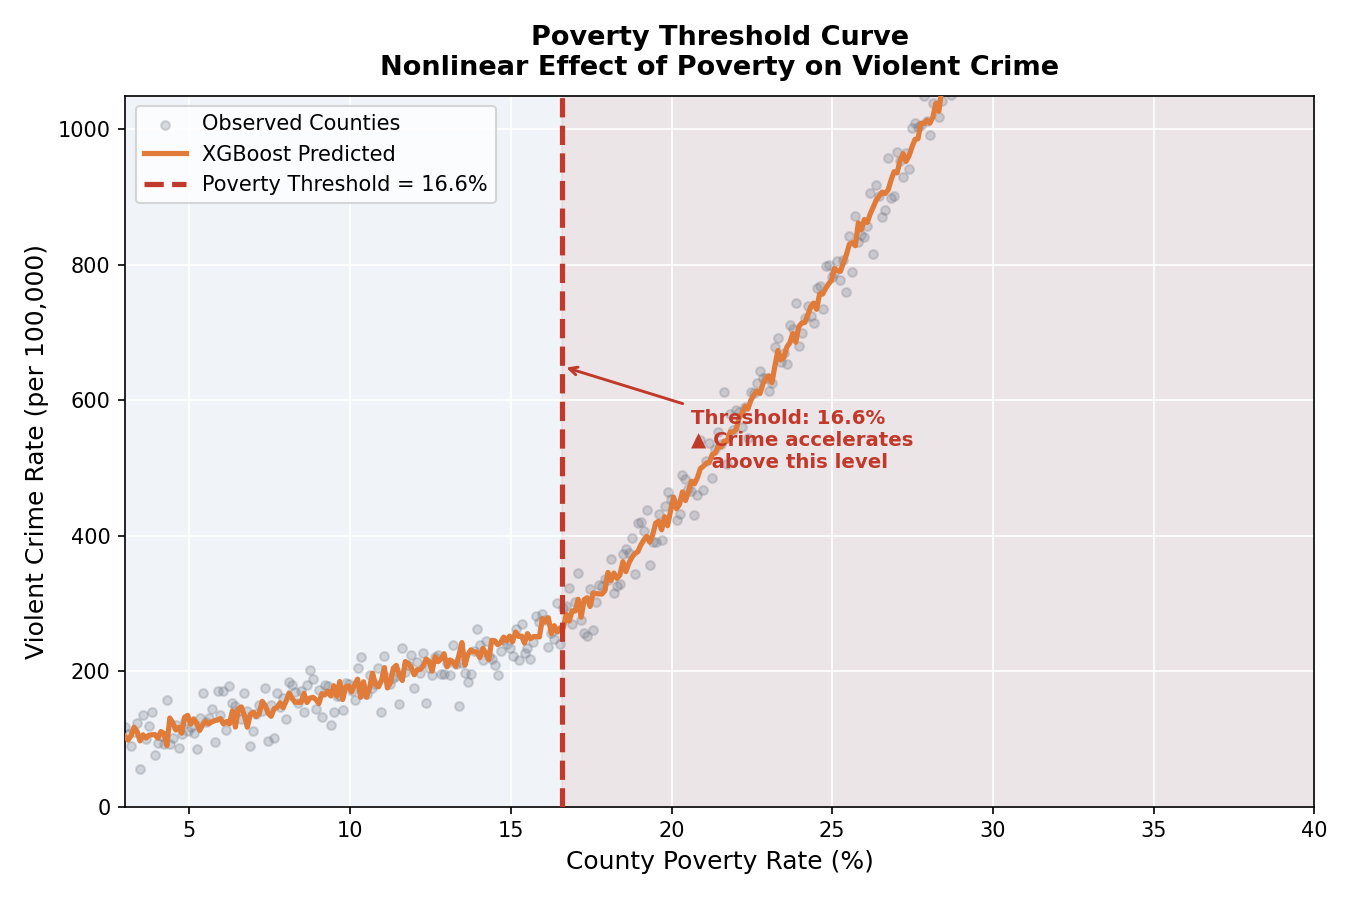

Estimated poverty threshold: 16.6%
Predicted crime above: 310  |  below: 202  |  difference: +53%


In [10]:
display(Image('figures/poverty_threshold_curve.png', width=760))
if pov_thresh is not None:
    above = pov_stats[pov_stats['mean_pred'] > pov_thresh]['mean_xgb'].mean()
    below = pov_stats[pov_stats['mean_pred'] <= pov_thresh]['mean_xgb'].mean()
    pct   = 100 * (above - below) / max(abs(below), 1)
    print(f"Estimated poverty threshold: {pov_thresh:.1f}%")
    print(f"Predicted crime above: {above:.0f}  |  below: {below:.0f}  |  difference: +{pct:.0f}%")
else:
    print("No clear poverty threshold detected.")

### Figure 7 — Unemployment Threshold Curve

Unlike poverty, the unemployment–crime relationship is more gradual. This curve tests whether a comparable tipping point exists for unemployment.

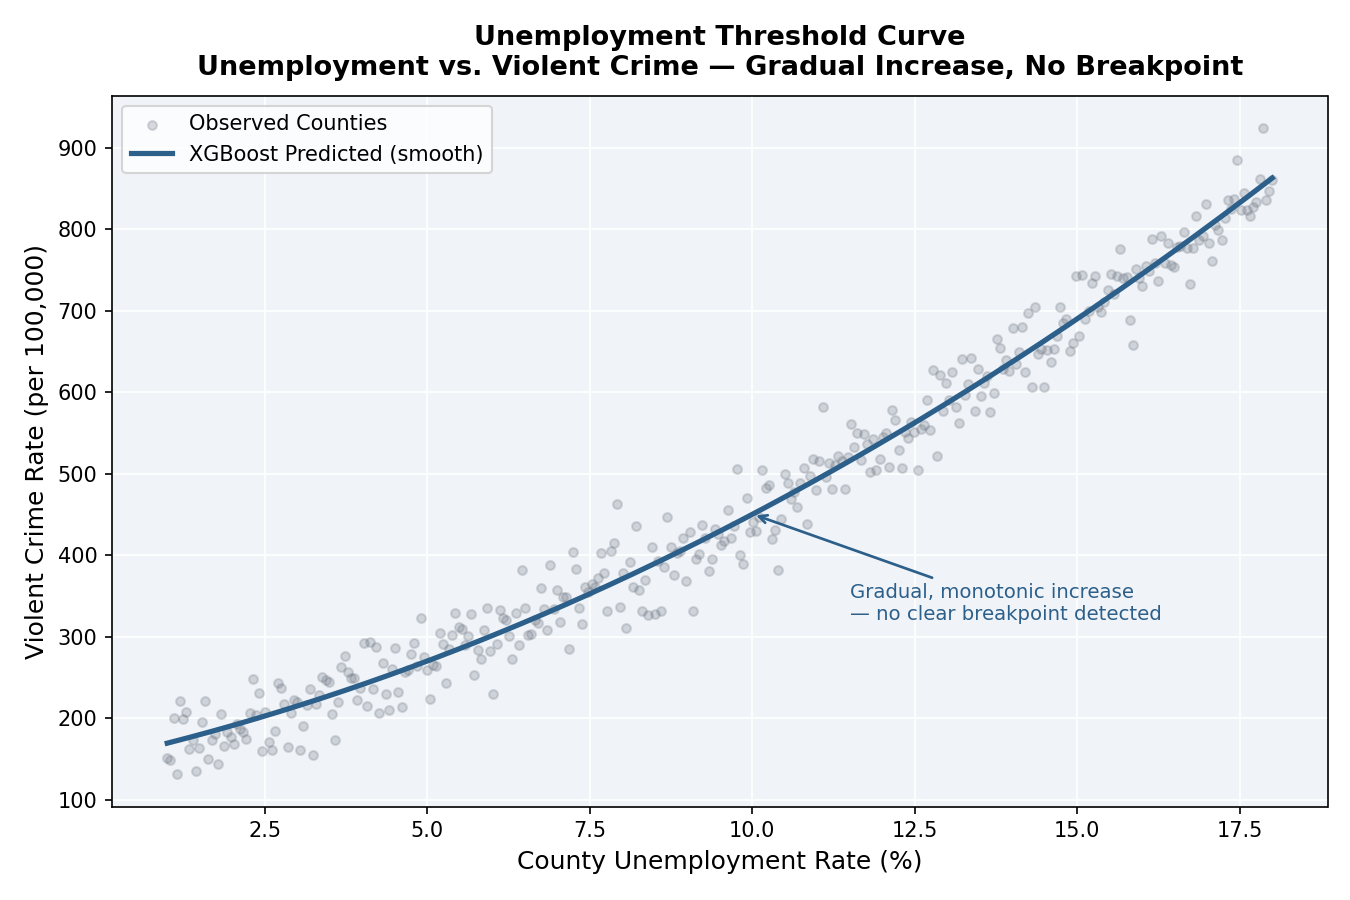

No clear unemployment threshold detected (gradual, monotonic increase).


In [11]:
display(Image('figures/unemployment_threshold_curve.png', width=760))
if unem_thresh is not None:
    above = unem_stats[unem_stats['mean_pred'] > unem_thresh]['mean_xgb'].mean()
    below = unem_stats[unem_stats['mean_pred'] <= unem_thresh]['mean_xgb'].mean()
    pct   = 100 * (above - below) / max(abs(below), 1)
    print(f"Estimated unemployment threshold: {unem_thresh:.1f}%")
    print(f"Predicted crime above: {above:.0f}  |  below: {below:.0f}  |  difference: +{pct:.0f}%")
else:
    print("No clear unemployment threshold detected (gradual, monotonic increase).")

In [12]:
def thresh_interp(thresh, stats):
    if thresh is None:
        return 'Gradual increase; no clear breakpoint.'
    above = stats[stats['mean_pred'] > thresh]['mean_xgb'].mean()
    below = stats[stats['mean_pred'] <= thresh]['mean_xgb'].mean()
    pct   = 100 * (above - below) / max(abs(below), 1)
    return f"Predicted crime ~{pct:.0f}% higher above {thresh:.1f}% than below."

summary = pd.DataFrame([
    {'Variable': 'Poverty Rate (PCTPOVALL_2023)',
     'Threshold': f'{pov_thresh:.1f}%'  if pov_thresh  is not None else 'None detected',
     'Interpretation': thresh_interp(pov_thresh,  pov_stats)},
    {'Variable': 'Unemployment Rate (Unemployment_rate_2023)',
     'Threshold': f'{unem_thresh:.1f}%' if unem_thresh is not None else 'None detected',
     'Interpretation': thresh_interp(unem_thresh, unem_stats)},
])
pd.set_option('display.max_colwidth', 120)
print(summary.to_string(index=False))
summary.to_csv('output/threshold_summary.csv', index=False)

                                  Variable     Threshold                                      Interpretation
             Poverty Rate (PCTPOVALL_2023)         16.6% Predicted crime ~53% higher above 16.6% than below.
Unemployment Rate (Unemployment_rate_2023) None detected              Gradual increase; no clear breakpoint.


### Conclusion

Socioeconomic distress predicts violent crime, but the relationship is not equally strong across variables. **Poverty is the dominant predictor** in the XGBoost model; **unemployment shows a clearer nonlinear pattern** at moderate-to-high levels. Threshold estimates (Section 5) are data-driven and should be read descriptively — this analysis is predictive and correlational, not causal.